<a href="https://colab.research.google.com/github/fabrito2006/MILAB04-MID/blob/develop/Laboratorio_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 04 - Mineria de Datos
## Alumno: Torres Alvaradao Fabricio Ismael
## Ciclo y carrera: 5C28A

## 1. Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando las librerías de Python que se indican, haga lo siguiente:

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# Concat data
data = pd.concat([X, y], axis=1)

### a. Por medio de la librería ‘Pandas’, lea la base de datos, asigne nombres para las columnas, realice una imputación para la variable ‘Bare Nuclei’ por medio de la mediana y cambie las categorías para la variable ‘Class’ de 2 o 4 por 0 o 1.

In [3]:
# Leemos la base de datos
data = pd.concat([X, y], axis=1)
data.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [4]:
# Funcion de etección de datos nulos
def columnas_con_nulos(data):
    columnas_nulas = data.columns[data.isnull().any()].tolist()
    return columnas_nulas

In [5]:
# Funcion para rellenar con la mediana
def rellenar_nulos_con_mediana(data, columnas):
    for columna in columnas:
        mediana = data[columna].median()
        data[columna] = data[columna].apply(lambda x: mediana if pd.isnull(x) else x)
        print(f"Se ha rellenado la columna '{columna}' con la mediana: {mediana}")
    return data

In [6]:
# Rellenar columnas
columnas_nulas = columnas_con_nulos(data)

data = rellenar_nulos_con_mediana(data, columnas_nulas)

Se ha rellenado la columna 'Bare_nuclei' con la mediana: 1.0


In [7]:
# Visualizamos los tipos en Class
data['Class'].value_counts()

,count
Class,
2,458
4,241


In [8]:
# Cambiamos las categorias de Class
data['Class'] = data['Class'].replace({2: 0, 4: 1})

# Visualizamos los cambios
data['Class'].value_counts()

,count
Class,
0,458
1,241


### b. Realice una detección de valores atípicos univariados por medio del método del rango intercuartílico con 3 de longitud a la derecha y 3 a la izquierda, y elimínelos. Además, realice una detección de valores atípicos multivariados por medio de las distancias de Mahalanobis y elimine aquellos valores que superen el valor de 30

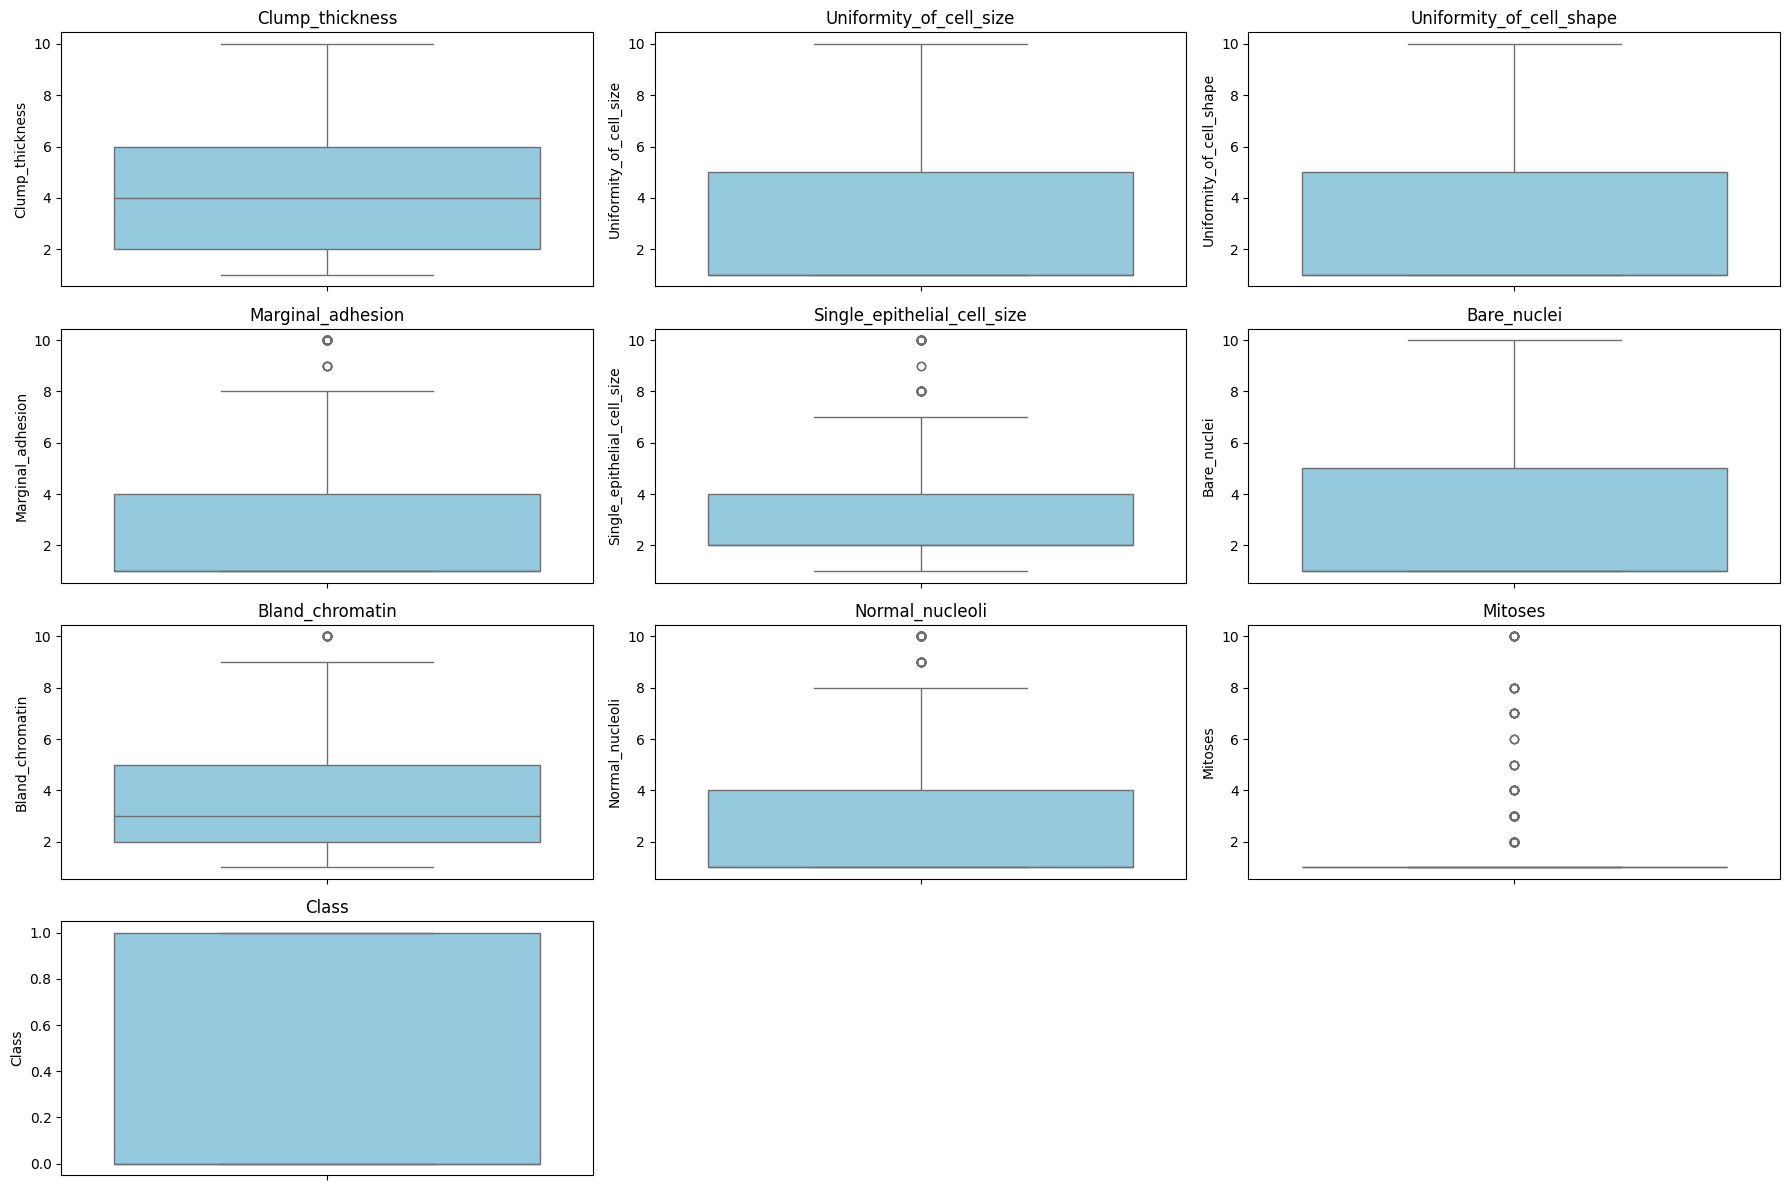

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))
for i, col in enumerate(data.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=data[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [12]:
# Seleccionamos mitoses y eliminamos atipicos
Q1 = data['Mitoses'].quantile(0.25)
Q3 = data['Mitoses'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR


data_filtrado = data[(data['Mitoses'] >= lower_bound) & (data['Mitoses'] <= upper_bound)]

# Verificamos que se hayan eliminado
len(data_filtrado)

579

In [16]:
import numpy as np
import pandas as pd
from scipy.spatial import distance
from numpy.linalg import inv

# Seleccionar las columnas nuevas
cols = ['Normal_nucleoli', 'Bland_chromatin']
data_subset = data[cols]

# Calcular la media y matriz de covarianza
mean_vec = data_subset.mean().values
cov_mat = np.cov(data_subset.values.T)
inv_cov_mat = inv(cov_mat)

# Calcular la distancia de Mahalanobis
mahalanobis_distances = data_subset.apply(
    lambda x: distance.mahalanobis(x, mean_vec, inv_cov_mat),
    axis=1
)

# Agregar la distancia al DataFrame original
data = data.copy()
data['Mahalanobis'] = mahalanobis_distances

# Detectar outliers con distancia > 30
outliers = data[data['Mahalanobis'] > 30]
print(f"Número de valores atípicos detectados: {len(outliers)}")

# Eliminar los outliers
data_filtrado = data[data['Mahalanobis'] <= 30].drop(columns=['Mahalanobis'])

Número de valores atípicos detectados: 0


No detecta ni uno ya que el umbral es bastante grande

### c. Realice un cálculo de los principales estadísticos descriptivos para las variables predictoras y cree dos conjuntos de datos: uno en donde se aplique la transformación Z-score y otro en donde se aplique la normalización mín-máx, sobre todas las variables predictoras.

In [17]:
# Preparamos la data
predictoras = data_filtrado.drop(columns=['Class'])
desc_stats = predictoras.describe()
print("Estadísticos descriptivos:\n")
print(desc_stats)

Estadísticos descriptivos:

       Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
count       699.000000               699.000000                699.000000   
mean          4.417740                 3.134478                  3.207439   
std           2.815741                 3.051459                  2.971913   
min           1.000000                 1.000000                  1.000000   
25%           2.000000                 1.000000                  1.000000   
50%           4.000000                 1.000000                  1.000000   
75%           6.000000                 5.000000                  5.000000   
max          10.000000                10.000000                 10.000000   

       Marginal_adhesion  Single_epithelial_cell_size  Bare_nuclei  \
count         699.000000                   699.000000   699.000000   
mean            2.806867                     3.216023     3.486409   
std             2.855379                     2.214300     3.621929  

In [18]:
# Z-score
z_score_df = (predictoras - predictoras.mean()) / predictoras.std()
z_score_df['Class'] = data['Class']

In [19]:
# Min-max
min_max_df = (predictoras - predictoras.min()) / (predictoras.max() - predictoras.min())
min_max_df['Class'] = data['Class']

In [21]:
# Visualizamos
print("📊 Conjunto de datos con transformación Z-score:")
z_score_df.head()

📊 Conjunto de datos con transformación Z-score:


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,0.206788,-0.699494,-0.742767,-0.632794,-0.549168,-0.686488,-0.179534,-0.611387,-0.343666,0
1,0.206788,0.283642,0.266684,0.768071,1.708882,1.798376,-0.179534,-0.283909,-0.343666,0
2,-0.503505,-0.699494,-0.742767,-0.632794,-0.549168,-0.410392,-0.179534,-0.611387,-0.343666,0
3,0.561934,1.594490,1.612618,-0.632794,-0.097558,0.141800,-0.179534,1.353485,-0.343666,0
4,-0.148359,-0.699494,-0.742767,0.067638,-0.549168,-0.686488,-0.179534,-0.611387,-0.343666,0


In [22]:
print("📊 Conjunto de datos con normalización Min-Max:")
min_max_df.head()

📊 Conjunto de datos con normalización Min-Max:


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,0.444444,0.000000,0.000000,0.000000,0.111111,0.000000,0.222222,0.000000,0.0,0
1,0.444444,0.333333,0.333333,0.444444,0.666667,1.000000,0.222222,0.111111,0.0,0
2,0.222222,0.000000,0.000000,0.000000,0.111111,0.111111,0.222222,0.000000,0.0,0
3,0.555556,0.777778,0.777778,0.000000,0.222222,0.333333,0.222222,0.666667,0.0,0
4,0.333333,0.000000,0.000000,0.222222,0.111111,0.000000,0.222222,0.000000,0.0,0
